# Wildfire Burn Prediction — Residual Stacking (v2)

Improves on the LightGBM hurdle baseline with a **Residual Stacking** model (Option A):
a small neural network that corrects LightGBM's errors.

**Key formula:** `final_prob = sigmoid(logit(p_lgbm) + α · δ)`  
where δ is the NN correction logit. If NN learns zero correction, we recover LightGBM exactly.
α is a learned scalar with L1 regularization pushing toward 0.

## §0  Master configuration

In [1]:
CFG = {
    "data_path": "../data/model_data_burned_area_01deg.parquet",
    "random_seed": 42,
    "target_mode": "hurdle",
    "temporal_test_years": 4,
    "temporal_val_years":  2,
    "spatial_test_frac":   0.15,
    "spatial_block_size":  3,
    "lgbm_binary": {
        "n_estimators": 1500, "learning_rate": 0.05, "num_leaves": 63,
        "min_child_samples": 50, "subsample": 0.8, "colsample_bytree": 0.8,
        "reg_alpha": 0.1, "reg_lambda": 1.0, "class_weight": "balanced",
        "early_stopping_rounds": 50, "verbose": -1,
    },
    "lgbm_regression": {
        "n_estimators": 1500, "learning_rate": 0.05, "num_leaves": 63,
        "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8,
        "reg_alpha": 0.1, "reg_lambda": 1.0, "objective": "regression",
        "early_stopping_rounds": 50, "verbose": -1,
    },
    # Residual NN
    "res_hidden_dims":   [128, 64],
    "res_dropout":        0.3,
    "res_weight_decay":   1e-4,
    "res_lr":             1e-3,
    "res_batch_size":     4096,
    "res_epochs":         60,
    "res_patience":       10,
    "res_balanced_frac":  0.30,
    "res_k_neighbors":    8,
    "focal_gamma":        2.0,
    "focal_alpha":        0.98,
    "conformal_coverage": 0.90,
}

import random, numpy as np
random.seed(CFG["random_seed"]); np.random.seed(CFG["random_seed"])
print("Config loaded. target_mode =", CFG["target_mode"])


Config loaded. target_mode = hurdle


## §1  Imports & dependency check

In [2]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_score, recall_score, mean_squared_error, mean_absolute_error, r2_score,
    precision_recall_curve, roc_curve,
)
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor

try:
    import torch, torch.nn as nn, torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
    TORCH_AVAILABLE = True
    torch.manual_seed(CFG["random_seed"])
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("PyTorch", torch.__version__, "| device:", DEVICE)
except ImportError:
    TORCH_AVAILABLE = False
    print("WARNING: PyTorch not found — residual NN will be skipped. pip install torch")

try:
    from scipy.spatial import cKDTree
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("WARNING: scipy not found — using manual fallback for spatial graph.")

print("LightGBM", lgb.__version__)


PyTorch 2.12.0+cpu | device: cpu
LightGBM 4.6.0


## §2  Data loading & feature groups

In [3]:
DATA_PATH = Path(CFG["data_path"])
if not DATA_PATH.exists():
    DATA_PATH = Path(r"c:\Users\fangshuye\OneDrive - Microsoft\Documents\Personal\WildFire\data\model_data_burned_area_01deg.parquet")

df = pd.read_parquet(DATA_PATH)

META_COLS     = ["lon","lat","year","month","water_year","cell_area_km2"]
RESPONSE_COLS = ["log_burned_area","burned_area_km2"]

FEATURE_GROUPS = {
    "1_standard_means":  ["tmmx","tmmn","pr","rmax","rmin","sph","srad","fm100","fm1000","erc","vpd","bi"],
    "2_wind":            ["wind_u_mean","wind_v_mean","wind_speed_mean","wind_speed_max"],
    "3_spei":            ["spei30d","spei90d","spei180d","spei270d"],
    "4_daily_extreme":   ["consec_dry_days","consec_hot_days","tmmx_p95","vpd_max","vpd_p95"],
    "5_anomalies":       ["temp_anomaly","tmax_anomaly","rmin_anomaly","vpd_anomaly","pr_anomaly"],
    "6_fm_lag":          ["fm100_lag1","fm100_lag2","fm100_lag3","fm1000_lag1","fm1000_lag2","fm1000_lag3"],
    "7_neighborhood":    ["fm100_nbr_mean","fm100_nbr_min","fm1000_nbr_mean","fm1000_nbr_min",
                          "vpd_nbr_mean","vpd_nbr_max","erc_nbr_mean","erc_nbr_max","bi_nbr_mean","bi_nbr_max"],
    "8_antecedent":      ["pr_avg1","pr_avg2","pr_avg3","spei30d_avg1","spei30d_avg2","spei30d_avg3",
                          "spei30d_avg4","spei30d_avg5","spei30d_avg6","tmean_avg1","tmean_avg2"],
    "9_fire_history":    ["burn_freq","burned_prev_wy"],
    "10_vegetation":     ["veg_Chaparral","veg_Conifer_Forest","veg_Grassland",
                          "veg_Oak_Woodland","veg_Redwoods_Alpine","veg_Shrub"],
    "11_lai":            ["lai","lai_avg_6mo","lai_neighbor_sum","lai_neighbor_sum_6mo"],
    "12_terrain":        ["slope_avg","slope_max"],
    "13_infrastructure": ["minor_line_density","pole_density","population_density","road_density",
                          "tower_density","trans_line_density","transformer_density"],
}
le = LabelEncoder()
df["ecoregion_enc"] = le.fit_transform(df["ecoregion"].astype(str))
FEATURE_GROUPS["10_vegetation"] = FEATURE_GROUPS["10_vegetation"] + ["ecoregion_enc"]

ALL_FEATURES = [c for g in FEATURE_GROUPS.values() for c in g if c in df.columns]
print(f"Features: {len(ALL_FEATURES)} | Rows: {len(df):,}")

df["burned"] = (df["burned_area_km2"] > 0).astype(int)
TARGET_BINARY = "burned"
TARGET_REGR   = "log_burned_area"

print(f"Burn rate: {df['burned'].mean():.4%}  |  imbalance 1:{(1-df['burned'].mean())/df['burned'].mean():.0f}")


Features: 79 | Rows: 661,248
Burn rate: 1.0051%  |  imbalance 1:98


## §3  CV & holdout split strategy

Two independent axes of held-out data:
- **Temporal OOT:** last `temporal_test_years` water-years
- **Spatial OOD:** `spatial_test_frac` of grid cells in contiguous blocks

In [4]:
def temporal_split(df, test_years: int, val_years: int):
    """Split by water_year. Returns train/val/test boolean masks."""
    years = sorted(df["water_year"].unique())
    test_cutoff = years[-test_years]
    val_cutoff  = years[-(test_years + val_years)]
    train_mask = df["water_year"] < val_cutoff
    val_mask   = (df["water_year"] >= val_cutoff) & (df["water_year"] < test_cutoff)
    test_mask  = df["water_year"] >= test_cutoff
    print(f"Temporal split — train:{train_mask.sum():,}  val:{val_mask.sum():,}  test:{test_mask.sum():,}")
    print(f"  train years: {df.loc[train_mask,'water_year'].min()}–{df.loc[train_mask,'water_year'].max()}")
    print(f"  val   years: {df.loc[val_mask,'water_year'].min()}–{df.loc[val_mask,'water_year'].max()}")
    print(f"  test  years: {df.loc[test_mask,'water_year'].min()}–{df.loc[test_mask,'water_year'].max()}")
    return train_mask, val_mask, test_mask


def spatial_block_split(df, test_frac: float, block_deg: float, seed: int):
    """Partition grid cells into blocks; hold out ~test_frac as spatial OOD test."""
    cells = df[["lat","lon"]].drop_duplicates().copy()
    cells["lat_block"] = (cells["lat"] // block_deg).astype(int)
    cells["lon_block"] = (cells["lon"] // block_deg).astype(int)
    cells["block_id"]  = cells["lat_block"].astype(str) + "_" + cells["lon_block"].astype(str)
    blocks = cells["block_id"].unique()
    rng    = np.random.default_rng(seed)
    n_test = max(1, int(len(blocks) * test_frac))
    test_blocks = set(rng.choice(blocks, size=n_test, replace=False))
    test_cells  = set(
        zip(cells.loc[cells["block_id"].isin(test_blocks), "lat"],
            cells.loc[cells["block_id"].isin(test_blocks), "lon"])
    )
    spat_mask = pd.Series(
        [(row.lat, row.lon) in test_cells for row in df[["lat","lon"]].itertuples()],
        index=df.index, dtype=bool
    )
    pct = spat_mask.mean() * 100
    print(f"Spatial OOD split — {n_test}/{len(blocks)} blocks → {spat_mask.sum():,} rows ({pct:.1f}%)")
    return spat_mask


def build_splits(df, cfg):
    """Build all splits; return a dict of boolean index masks."""
    tr_mask, val_mask, test_t_mask = temporal_split(
        df, cfg["temporal_test_years"], cfg["temporal_val_years"]
    )
    test_s_mask = spatial_block_split(
        df, cfg["spatial_test_frac"], cfg["spatial_block_size"], cfg["random_seed"]
    )
    excl_mask = test_t_mask | test_s_mask
    tr_mask   = tr_mask & ~excl_mask
    val_mask  = val_mask & ~test_s_mask
    print(f"\nFinal: train={tr_mask.sum():,}  val={val_mask.sum():,}  "
          f"test_temporal={test_t_mask.sum():,}  test_spatial={test_s_mask.sum():,}")
    return {"train": tr_mask, "val": val_mask,
            "test_temporal": test_t_mask, "test_spatial": test_s_mask}


splits = build_splits(df, CFG)


Temporal split — train:495,936  val:55,104  test:110,208
  train years: 2001–2018
  val   years: 2019–2020
  test  years: 2021–2024
Spatial OOD split — 2/14 blocks → 3,456 rows (0.5%)

Final: train=493,344  val=54,816  test_temporal=110,208  test_spatial=3,456


## §4  Evaluation helpers

In [5]:
def eval_binary(y_true, y_prob, threshold=0.5, name="model"):
    """Full binary classification evaluation."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "model":      name,
        "pr_auc":     average_precision_score(y_true, y_prob),
        "roc_auc":    roc_auc_score(y_true, y_prob),
        "f1":         f1_score(y_true, y_pred, zero_division=0),
        "precision":  precision_score(y_true, y_pred, zero_division=0),
        "recall":     recall_score(y_true, y_pred, zero_division=0),
        "n_pos_pred": int(y_pred.sum()),
        "n_pos_true": int(y_true.sum()),
        "threshold":  threshold,
    }


def eval_regression(y_true, y_pred, name="model", log_space=True):
    """Full regression evaluation. Assumes log-transformed targets if log_space=True."""
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt, yp = y_true[mask], y_pred[mask]
    res = {
        "model": name,
        "rmse":  float(np.sqrt(mean_squared_error(yt, yp))),
        "mae":   float(mean_absolute_error(yt, yp)),
        "r2":    float(r2_score(yt, yp)),
    }
    if log_space:
        yt_orig = np.expm1(np.clip(yt, -30, 30))
        yp_orig = np.expm1(np.clip(yp, -30, 30))
        res["log_rmse"] = float(np.sqrt(mean_squared_error(
            np.log1p(yt_orig), np.log1p(np.clip(yp_orig, 0, None)))))
    return res


def find_threshold_at_recall(y_true, y_prob, target_recall=0.80):
    """Return lowest threshold achieving >= target_recall."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    mask = rec[:-1] >= target_recall
    if not mask.any():
        return float(thr[-1])
    return float(thr[mask][-1])


def conformal_threshold(cal_probs, cal_labels, coverage=0.90):
    """
    Class-conditional split conformal prediction.
    P(predict burned | truly burned) >= coverage.
    """
    pos_mask  = cal_labels == 1
    pos_probs = cal_probs[pos_mask]
    n_pos     = pos_mask.sum()

    if n_pos < 20:
        print(f"WARNING: Only {n_pos} positives — falling back to recall-targeting threshold.")
        return find_threshold_at_recall(cal_labels, cal_probs, target_recall=coverage)

    scores  = 1.0 - pos_probs
    q_level = np.ceil(coverage * (n_pos + 1)) / n_pos
    q_level = np.clip(q_level, 0.0, 1.0)
    q       = np.quantile(scores, q_level)
    tau     = float(np.clip(1.0 - q, 0.0, 1.0))

    pos_cov = (pos_probs >= tau).mean()
    all_fpr = (cal_probs[cal_labels == 0] >= tau).mean()
    print(f"Conformal tau={tau:.4f} | "
          f"positive-class coverage={pos_cov:.3%} (target={coverage:.0%}) | "
          f"FPR={all_fpr:.4%} | n_pos_cal={n_pos}")
    return tau


def print_results(results_list, title=""):
    df_r = pd.DataFrame(results_list)
    print(f"\n{'='*60}\n{title}\n{'='*60}")
    print(df_r.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return df_r


results_binary     = []
results_regression = []
curves_store       = {}
print("Evaluation helpers ready.")


Evaluation helpers ready.


## §5  Baseline — LightGBM Hurdle Model

- **Stage 1 (binary):** LGBMClassifier with class_weight='balanced'
- **Stage 2 (regression):** LGBMRegressor trained on positives only

In [6]:
X_train  = df.loc[splits["train"],         ALL_FEATURES].values.astype(np.float32)
X_val    = df.loc[splits["val"],           ALL_FEATURES].values.astype(np.float32)
X_test_t = df.loc[splits["test_temporal"], ALL_FEATURES].values.astype(np.float32)
X_test_s = df.loc[splits["test_spatial"],  ALL_FEATURES].values.astype(np.float32)

y_bin_train  = df.loc[splits["train"],         TARGET_BINARY].values
y_bin_val    = df.loc[splits["val"],           TARGET_BINARY].values
y_bin_test_t = df.loc[splits["test_temporal"], TARGET_BINARY].values
y_bin_test_s = df.loc[splits["test_spatial"],  TARGET_BINARY].values

y_reg_train  = df.loc[splits["train"],         TARGET_REGR].values
y_reg_val    = df.loc[splits["val"],           TARGET_REGR].values
y_reg_test_t = df.loc[splits["test_temporal"], TARGET_REGR].values
y_reg_test_s = df.loc[splits["test_spatial"],  TARGET_REGR].values

# Stage 1: binary classifier
lgbm_clf_params = {k: v for k, v in CFG["lgbm_binary"].items()
                   if k not in ("early_stopping_rounds",)}
lgbm_clf = LGBMClassifier(**lgbm_clf_params)
lgbm_clf.fit(
    X_train, y_bin_train,
    eval_set=[(X_val, y_bin_val)],
    callbacks=[lgb.early_stopping(CFG["lgbm_binary"]["early_stopping_rounds"], verbose=False),
               lgb.log_evaluation(period=100)],
)
print(f"Best iteration (binary): {lgbm_clf.best_iteration_}")

# Stage 2: regression on positives only
pos_train = y_bin_train == 1
pos_val   = y_bin_val   == 1
lgbm_reg_params = {k: v for k, v in CFG["lgbm_regression"].items()
                   if k not in ("early_stopping_rounds", "objective")}
lgbm_reg = LGBMRegressor(**lgbm_reg_params)
lgbm_reg.fit(
    X_train[pos_train], y_reg_train[pos_train],
    eval_set=[(X_val[pos_val], y_reg_val[pos_val])],
    callbacks=[lgb.early_stopping(CFG["lgbm_regression"]["early_stopping_rounds"], verbose=False),
               lgb.log_evaluation(period=100)],
)
print(f"Best iteration (regression): {lgbm_reg.best_iteration_}")


[100]	valid_0's binary_logloss: 0.363545
[200]	valid_0's binary_logloss: 0.284793
[300]	valid_0's binary_logloss: 0.233516
[400]	valid_0's binary_logloss: 0.196034
[500]	valid_0's binary_logloss: 0.169709
[600]	valid_0's binary_logloss: 0.148161
[700]	valid_0's binary_logloss: 0.130334
[800]	valid_0's binary_logloss: 0.116367
[900]	valid_0's binary_logloss: 0.105011
[1000]	valid_0's binary_logloss: 0.0961198
[1100]	valid_0's binary_logloss: 0.0881085
[1200]	valid_0's binary_logloss: 0.0824623
[1300]	valid_0's binary_logloss: 0.0778764
[1400]	valid_0's binary_logloss: 0.0746869
[1500]	valid_0's binary_logloss: 0.0717571
Best iteration (binary): 1500
Best iteration (regression): 37


In [7]:
# Evaluate LGBM baseline with conformal threshold calibrated on val set
cal_prob_val   = lgbm_clf.predict_proba(X_val)[:, 1]
cal_labels_val = y_bin_val


def evaluate_lgbm_hurdle(X, y_bin, y_reg, split_name):
    """Evaluate LGBM hurdle on a test split using conformal threshold."""
    prob = lgbm_clf.predict_proba(X)[:, 1]
    curves_store[f"LGBM_Hurdle_{split_name}"] = (y_bin.copy(), prob.copy())
    tau = conformal_threshold(cal_prob_val, cal_labels_val, CFG["conformal_coverage"])

    bin_res = eval_binary(y_bin, prob, threshold=tau, name=f"LightGBM_{split_name}")
    results_binary.append(bin_res)

    pred_burned = (prob >= tau)
    y_reg_pred  = np.zeros(len(y_reg))
    if pred_burned.sum() > 0:
        y_reg_pred[pred_burned] = lgbm_reg.predict(X[pred_burned])
    reg_res = eval_regression(y_reg, y_reg_pred, name=f"LightGBM_{split_name}")
    results_regression.append(reg_res)
    return bin_res, reg_res


print("Running LGBM baseline on test sets...")
evaluate_lgbm_hurdle(X_test_t, y_bin_test_t, y_reg_test_t, "TemporalOOT")
evaluate_lgbm_hurdle(X_test_s, y_bin_test_s, y_reg_test_s, "SpatialOOD")
print("Done.")
print_results(results_binary,     "LGBM Binary Results")
print_results(results_regression, "LGBM Regression Results")


Running LGBM baseline on test sets...
Conformal tau=0.0019 | positive-class coverage=90.176% (target=90%) | FPR=46.1318% | n_pos_cal=682
Conformal tau=0.0019 | positive-class coverage=90.176% (target=90%) | FPR=46.1318% | n_pos_cal=682
Done.

LGBM Binary Results
               model  pr_auc  roc_auc     f1  precision  recall  n_pos_pred  n_pos_true  threshold
LightGBM_TemporalOOT  0.0492   0.7976 0.0432     0.0222  0.8666       49253        1259     0.0019
 LightGBM_SpatialOOD  0.0254   0.8716 0.0243     0.0123  0.8462         894          13     0.0019

LGBM Regression Results
               model   rmse    mae       r2  log_rmse
LightGBM_TemporalOOT 0.5903 0.3491 -10.1703    0.5903
 LightGBM_SpatialOOD 0.3646 0.1652  -3.0977    0.3646


,model,rmse,mae,r2,log_rmse
0,LightGBM_TemporalOOT,0.590300,0.349075,-10.170299,0.590300
1,LightGBM_SpatialOOD,0.364572,0.165151,-3.097670,0.364572


## §6  Residual Stacking (Option A)

The NN focuses only on patterns in LightGBM's errors:

```
final_logit = logit(p_lgbm) + α · δ_nn
final_prob  = sigmoid(final_logit)
```

- **δ_nn** = correction logit from small MLP
- **α** = learned scalar (init 0.5, L1-regularized toward 0)
- If NN learns δ=0 or α=0, final_prob = p_lgbm exactly

### §6a  Spatial neighbor graph (k-NN on grid cells)

In [8]:
if not TORCH_AVAILABLE:
    print("Skipping residual stacking — PyTorch not available.")
else:
    K_NBR = CFG["res_k_neighbors"]

    grid_cells = df[["lat","lon"]].drop_duplicates().sort_values(["lat","lon"]).reset_index(drop=True)
    coords     = grid_cells[["lat","lon"]].values  # (N_cells, 2)
    N_cells    = len(grid_cells)

    if SCIPY_AVAILABLE:
        tree       = cKDTree(coords)
        _, nbr_idx = tree.query(coords, k=K_NBR + 1)
        nbr_idx    = nbr_idx[:, 1:]   # drop self; shape (N_cells, K_NBR)
    else:
        diff    = coords[:, None] - coords[None, :]
        dists   = np.sqrt((diff**2).sum(-1))
        nbr_idx = np.argsort(dists, axis=1)[:, 1:K_NBR + 1]

    cell_to_idx = {(r.lat, r.lon): i for i, r in grid_cells.iterrows()}
    df["cell_idx"] = df.apply(lambda r: cell_to_idx[(r.lat, r.lon)], axis=1)

    nbr_idx_arr = nbr_idx  # numpy (N_cells, K_NBR)
    print(f"Spatial graph built: {N_cells} cells x {K_NBR} neighbors each.")


Spatial graph built: 2296 cells x 8 neighbors each.


### §6b  Build residual NN inputs

Input = [p_lgbm (1) | X_scaled (79) | nbr_residual_signal (1)] → 81 dims  
**Leakage prevention:** neighbor residuals are computed from TRAINING residuals only.

In [9]:
if not TORCH_AVAILABLE:
    pass
else:
    # LightGBM predicted probabilities on all splits
    p_lgbm_train  = lgbm_clf.predict_proba(X_train)[:, 1].astype(np.float32)
    p_lgbm_val    = lgbm_clf.predict_proba(X_val)[:, 1].astype(np.float32)
    p_lgbm_test_t = lgbm_clf.predict_proba(X_test_t)[:, 1].astype(np.float32)
    p_lgbm_test_s = lgbm_clf.predict_proba(X_test_s)[:, 1].astype(np.float32)

    # Training residuals: y_true - p_hat (binary)
    res_train = y_bin_train.astype(np.float32) - p_lgbm_train

    # Cell-level mean residual (from training only — no leakage)
    cell_res_sum   = np.zeros(N_cells, dtype=np.float64)
    cell_res_count = np.zeros(N_cells, dtype=np.float64)
    train_cell_idx = df.loc[splits["train"], "cell_idx"].values
    for ci, ri in zip(train_cell_idx, res_train):
        cell_res_sum[ci]   += ri
        cell_res_count[ci] += 1
    cell_res_mean = np.where(cell_res_count > 0,
                             cell_res_sum / np.maximum(cell_res_count, 1), 0.0).astype(np.float32)

    def compute_nbr_residual_signal(cell_idxs):
        """Mean training residual across k-NN neighbors (no leakage)."""
        return np.array([cell_res_mean[nbr_idx_arr[ci]].mean() for ci in cell_idxs],
                        dtype=np.float32)

    print("Computing neighbor residual signals...")
    nbr_sig_train  = compute_nbr_residual_signal(df.loc[splits["train"],         "cell_idx"].values)
    nbr_sig_val    = compute_nbr_residual_signal(df.loc[splits["val"],           "cell_idx"].values)
    nbr_sig_test_t = compute_nbr_residual_signal(df.loc[splits["test_temporal"], "cell_idx"].values)
    nbr_sig_test_s = compute_nbr_residual_signal(df.loc[splits["test_spatial"],  "cell_idx"].values)

    # Scale features (fit on training only)
    feat_scaler = StandardScaler()
    X_train_sc  = feat_scaler.fit_transform(X_train).astype(np.float32)
    X_val_sc    = feat_scaler.transform(X_val).astype(np.float32)
    X_test_t_sc = feat_scaler.transform(X_test_t).astype(np.float32)
    X_test_s_sc = feat_scaler.transform(X_test_s).astype(np.float32)

    def build_res_input(X_sc, p_lgbm, nbr_sig):
        """Concatenate [p_lgbm | X_scaled | nbr_sig] -> (N, 81)."""
        return np.concatenate([
            p_lgbm.reshape(-1, 1),
            X_sc,
            nbr_sig.reshape(-1, 1),
        ], axis=1).astype(np.float32)

    Xr_train  = build_res_input(X_train_sc,  p_lgbm_train,  nbr_sig_train)
    Xr_val    = build_res_input(X_val_sc,    p_lgbm_val,    nbr_sig_val)
    Xr_test_t = build_res_input(X_test_t_sc, p_lgbm_test_t, nbr_sig_test_t)
    Xr_test_s = build_res_input(X_test_s_sc, p_lgbm_test_s, nbr_sig_test_s)
    print(f"Residual NN input shape: {Xr_train.shape}  (1 p_lgbm + 79 features + 1 nbr_sig)")

    # Cache LGBM regression predictions for residual computation
    yhat_reg_train  = np.zeros(len(y_reg_train),  dtype=np.float32)
    yhat_reg_val    = np.zeros(len(y_reg_val),    dtype=np.float32)
    yhat_reg_test_t = np.zeros(len(y_reg_test_t), dtype=np.float32)
    yhat_reg_test_s = np.zeros(len(y_reg_test_s), dtype=np.float32)
    yhat_reg_train[pos_train] = lgbm_reg.predict(X_train[pos_train]).astype(np.float32)
    yhat_reg_val[pos_val]     = lgbm_reg.predict(X_val[pos_val]).astype(np.float32)
    yhat_reg_test_t[:]        = lgbm_reg.predict(X_test_t).astype(np.float32)
    yhat_reg_test_s[:]        = lgbm_reg.predict(X_test_s).astype(np.float32)
    print("LGBM predictions cached.")


Computing neighbor residual signals...
Residual NN input shape: (493344, 81)  (1 p_lgbm + 79 features + 1 nbr_sig)
LGBM predictions cached.


### §6c  Dataset & balanced sampler

In [10]:
if not TORCH_AVAILABLE:
    pass
else:
    class ResidualDataset(Dataset):
        """Dataset for residual binary head training."""
        def __init__(self, Xr, y_bin, p_lgbm):
            self.Xr     = torch.tensor(Xr,     dtype=torch.float32)
            self.y_bin  = torch.tensor(y_bin,  dtype=torch.float32)
            self.p_lgbm = torch.tensor(p_lgbm, dtype=torch.float32)
        def __len__(self): return len(self.Xr)
        def __getitem__(self, i):
            return self.Xr[i], self.y_bin[i], self.p_lgbm[i]


    class ResidualRegrDataset(Dataset):
        """Dataset for regression correction head (positive samples only)."""
        def __init__(self, Xr, y_bin, p_lgbm, y_reg, yhat_lgbm):
            mask        = y_bin == 1
            self.Xr     = torch.tensor(Xr[mask],                           dtype=torch.float32)
            self.p_lgbm = torch.tensor(p_lgbm[mask],                       dtype=torch.float32)
            self.resid  = torch.tensor((y_reg[mask] - yhat_lgbm[mask]).astype(np.float32),
                                       dtype=torch.float32)
        def __len__(self): return len(self.Xr)
        def __getitem__(self, i):
            return self.Xr[i], self.p_lgbm[i], self.resid[i]


    def make_balanced_loader(Xr, y_bin, p_lgbm, batch_size, pos_frac):
        ds    = ResidualDataset(Xr, y_bin, p_lgbm)
        y     = y_bin.astype(np.float32)
        n_pos = int(y.sum()); n_neg = int((1 - y).sum())
        w_pos = pos_frac / max(n_pos, 1)
        w_neg = (1 - pos_frac) / max(n_neg, 1)
        weights = np.where(y == 1, w_pos, w_neg)
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(weights, dtype=torch.double),
            num_samples=len(ds), replacement=True
        )
        print(f"  Balanced sampler: {pos_frac:.0%} positives target "
              f"({n_pos} pos / {n_neg} neg in pool)")
        return DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=0)


    BS = CFG["res_batch_size"]
    loader_res_train = make_balanced_loader(
        Xr_train, y_bin_train, p_lgbm_train, BS, CFG["res_balanced_frac"])
    loader_res_val   = DataLoader(
        ResidualDataset(Xr_val, y_bin_val, p_lgbm_val),
        batch_size=BS, shuffle=False, num_workers=0)
    print("Residual datasets ready.")


  Balanced sampler: 30% positives target (4695 pos / 488649 neg in pool)
Residual datasets ready.


### §6d  Residual MLP model

- Binary head: input(81) → 128 → ReLU → Dropout → 64 → ReLU → Dropout → 1 (logit δ)
- Final linear initialized to zero → early training ≈ LGBM baseline
- Regression head: same architecture + 1 extra input (p_bin_final) → scalar correction

In [11]:
if not TORCH_AVAILABLE:
    pass
else:
    class FocalLoss(nn.Module):
        """Focal loss for severe class imbalance."""
        def __init__(self, gamma=2.0, alpha=0.98, reduction="mean"):
            super().__init__()
            self.gamma = gamma
            self.alpha = alpha       # weight for NEGATIVE class
            self.reduction = reduction

        def forward(self, logits, targets):
            bce    = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
            p      = torch.sigmoid(logits)
            p_t    = targets * p + (1 - targets) * (1 - p)
            alpha_t = targets * (1 - self.alpha) + (1 - targets) * self.alpha
            fl     = alpha_t * (1 - p_t) ** self.gamma * bce
            if self.reduction == "mean":  return fl.mean()
            if self.reduction == "sum":   return fl.sum()
            return fl


    class ResidualMLP(nn.Module):
        """
        Binary correction MLP.
        Input: [p_lgbm (1) | X_scaled (79) | nbr_sig (1)]
        Output: final logit = logit(p_lgbm) + alpha * delta
        """
        def __init__(self, in_dim, hidden_dims, dropout):
            super().__init__()
            layers, prev = [], in_dim
            for h in hidden_dims:
                layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
                prev = h
            self.trunk    = nn.Sequential(*layers)
            self.out_head = nn.Linear(prev, 1)
            # alpha: learned blend scalar (L1 regularization in training loop)
            self.alpha    = nn.Parameter(torch.tensor(0.5))
            # zero init -> early training is exactly LGBM
            nn.init.zeros_(self.out_head.weight)
            nn.init.zeros_(self.out_head.bias)

        def forward(self, xr, p_lgbm):
            delta      = self.out_head(self.trunk(xr)).squeeze(1)
            p_clip     = torch.clamp(p_lgbm, 1e-6, 1 - 1e-6)
            logit_lgbm = torch.log(p_clip / (1 - p_clip))
            return logit_lgbm + self.alpha * delta

        def predict_proba(self, xr, p_lgbm):
            with torch.no_grad():
                return torch.sigmoid(self.forward(xr, p_lgbm))


    class ResidualRegrMLP(nn.Module):
        """Regression correction MLP for burned cells."""
        def __init__(self, in_dim, hidden_dims, dropout):
            super().__init__()
            layers, prev = [], in_dim
            for h in hidden_dims:
                layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
                prev = h
            self.trunk    = nn.Sequential(*layers)
            self.out_head = nn.Linear(prev, 1)
            nn.init.zeros_(self.out_head.weight)
            nn.init.zeros_(self.out_head.bias)

        def forward(self, xr):
            return self.out_head(self.trunk(xr)).squeeze(1)


    IN_DIM  = Xr_train.shape[1]      # 81
    HDIMS   = CFG["res_hidden_dims"]  # [128, 64]
    DROPOUT = CFG["res_dropout"]

    res_bin_model = ResidualMLP(IN_DIM, HDIMS, DROPOUT).to(DEVICE)
    n_params = sum(p.numel() for p in res_bin_model.parameters() if p.requires_grad)
    print(f"ResidualMLP (binary) parameters: {n_params:,}")
    print(f"  Input dim: {IN_DIM}  |  alpha initial: {res_bin_model.alpha.item():.3f}")


ResidualMLP (binary) parameters: 18,818
  Input dim: 81  |  alpha initial: 0.500


### §6e  Training — binary correction head

In [12]:
if not TORCH_AVAILABLE:
    pass
else:
    focal_loss_fn = FocalLoss(gamma=CFG["focal_gamma"], alpha=CFG["focal_alpha"])
    optimizer_bin = torch.optim.Adam(
        res_bin_model.parameters(),
        lr=CFG["res_lr"], weight_decay=CFG["res_weight_decay"]
    )
    scheduler_bin = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_bin, mode="min", patience=5, factor=0.5)

    best_val_loss = float("inf")
    best_state    = None
    patience_cnt  = 0
    train_losses, val_losses = [], []

    print(f"Training binary correction head ({CFG['res_epochs']} epochs, "
          f"patience={CFG['res_patience']})...")

    for epoch in range(1, CFG["res_epochs"] + 1):
        # Train
        res_bin_model.train()
        tr_loss, tr_b = 0.0, 0
        for xr_b, yb_b, pb_b in loader_res_train:
            xr_b = xr_b.to(DEVICE); yb_b = yb_b.to(DEVICE); pb_b = pb_b.to(DEVICE)
            optimizer_bin.zero_grad()
            logit = res_bin_model(xr_b, pb_b)
            loss  = focal_loss_fn(logit, yb_b)
            loss  = loss + 0.01 * res_bin_model.alpha.abs()   # L1 on alpha
            loss.backward()
            torch.nn.utils.clip_grad_norm_(res_bin_model.parameters(), 1.0)
            optimizer_bin.step()
            tr_loss += loss.item(); tr_b += 1
        tr_loss /= max(tr_b, 1)

        # Validate
        res_bin_model.eval()
        val_loss, val_b = 0.0, 0
        with torch.no_grad():
            for xr_b, yb_b, pb_b in loader_res_val:
                xr_b = xr_b.to(DEVICE); yb_b = yb_b.to(DEVICE); pb_b = pb_b.to(DEVICE)
                val_loss += focal_loss_fn(res_bin_model(xr_b, pb_b), yb_b).item()
                val_b    += 1
        val_loss /= max(val_b, 1)

        train_losses.append(tr_loss); val_losses.append(val_loss)
        scheduler_bin.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in res_bin_model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{CFG['res_epochs']} | "
                  f"train={tr_loss:.4f}  val={val_loss:.4f}  "
                  f"alpha={res_bin_model.alpha.item():.3f}  "
                  f"patience={patience_cnt}")

        if patience_cnt >= CFG["res_patience"]:
            print(f"  Early stopping at epoch {epoch}.")
            break

    res_bin_model.load_state_dict(best_state)
    res_bin_model.eval()
    print(f"\nBest val loss: {best_val_loss:.4f} | Final alpha: {res_bin_model.alpha.item():.4f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_losses, label="train"); ax.plot(val_losses, label="val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Focal Loss")
    ax.set_title("Binary Correction Head — Training Curves")
    ax.legend(); plt.tight_layout(); plt.show()


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

### §6e-2  Training — regression correction head

Training regression correction head (60 epochs, patience=10)...
  Epoch   1/60 | train=0.5157  val=1.4836  patience=0
  Epoch   5/60 | train=0.5783  val=1.4714  patience=0
  Epoch  10/60 | train=0.5592  val=1.4512  patience=0
  Epoch  15/60 | train=0.5318  val=1.4426  patience=2
  Epoch  20/60 | train=0.5423  val=1.4356  patience=7
  Early stopping at epoch 23.

Best regression val MSE: 1.4347


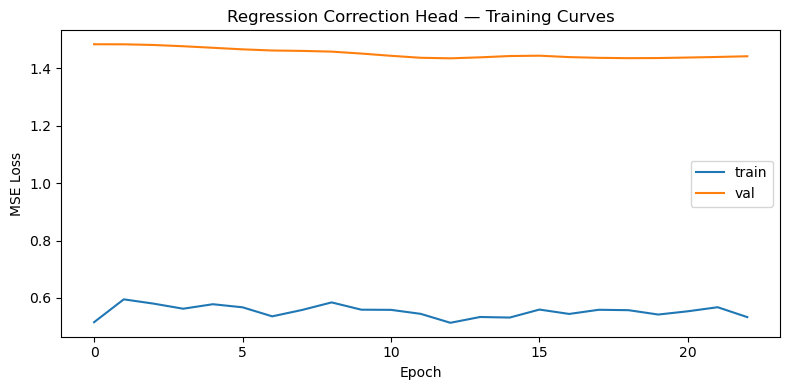

In [13]:
if not TORCH_AVAILABLE:
    pass
else:
    # Get binary model proba on train/val (as extra input for regression head)
    res_bin_model.eval()
    with torch.no_grad():
        p_final_train = res_bin_model.predict_proba(
            torch.tensor(Xr_train, dtype=torch.float32).to(DEVICE),
            torch.tensor(p_lgbm_train, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()
        p_final_val = res_bin_model.predict_proba(
            torch.tensor(Xr_val, dtype=torch.float32).to(DEVICE),
            torch.tensor(p_lgbm_val, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    # Append p_final as extra feature for regression head  (N, 82)
    Xr_reg_train = np.concatenate([Xr_train, p_final_train.reshape(-1, 1)], axis=1).astype(np.float32)
    Xr_reg_val   = np.concatenate([Xr_val,   p_final_val.reshape(-1, 1)],  axis=1).astype(np.float32)

    ds_reg_train = ResidualRegrDataset(
        Xr_reg_train, y_bin_train, p_lgbm_train, y_reg_train, yhat_reg_train)
    ds_reg_val   = ResidualRegrDataset(
        Xr_reg_val,   y_bin_val,   p_lgbm_val,   y_reg_val,   yhat_reg_val)

    loader_reg_train = DataLoader(ds_reg_train, batch_size=CFG["res_batch_size"],
                                  shuffle=True, num_workers=0)
    loader_reg_val   = DataLoader(ds_reg_val,   batch_size=CFG["res_batch_size"],
                                  shuffle=False, num_workers=0)

    IN_DIM_REG    = Xr_reg_train.shape[1]   # 82
    res_reg_model = ResidualRegrMLP(IN_DIM_REG, HDIMS, DROPOUT).to(DEVICE)
    optimizer_reg = torch.optim.Adam(
        res_reg_model.parameters(),
        lr=CFG["res_lr"], weight_decay=CFG["res_weight_decay"]
    )
    scheduler_reg = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_reg, mode="min", patience=5, factor=0.5)
    mse_loss_fn   = nn.MSELoss()

    best_reg_val  = float("inf")
    best_reg_state = None
    pat_reg       = 0
    reg_tr_losses, reg_val_losses = [], []

    print(f"Training regression correction head ({CFG['res_epochs']} epochs, "
          f"patience={CFG['res_patience']})...")
    if len(ds_reg_train) == 0:
        print("  No positive training samples — skipping regression head training.")
    else:
        for epoch in range(1, CFG["res_epochs"] + 1):
            res_reg_model.train()
            tr_loss, tr_b = 0.0, 0
            for xr_b, pb_b, resid_b in loader_reg_train:
                xr_b = xr_b.to(DEVICE); resid_b = resid_b.to(DEVICE)
                optimizer_reg.zero_grad()
                loss = mse_loss_fn(res_reg_model(xr_b), resid_b)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(res_reg_model.parameters(), 1.0)
                optimizer_reg.step()
                tr_loss += loss.item(); tr_b += 1
            tr_loss /= max(tr_b, 1)

            res_reg_model.eval()
            val_loss, val_b = 0.0, 0
            with torch.no_grad():
                for xr_b, pb_b, resid_b in loader_reg_val:
                    xr_b = xr_b.to(DEVICE); resid_b = resid_b.to(DEVICE)
                    val_loss += mse_loss_fn(res_reg_model(xr_b), resid_b).item()
                    val_b    += 1
            val_loss /= max(val_b, 1)

            reg_tr_losses.append(tr_loss); reg_val_losses.append(val_loss)
            scheduler_reg.step(val_loss)

            if val_loss < best_reg_val:
                best_reg_val   = val_loss
                best_reg_state = {k: v.cpu().clone() for k, v in res_reg_model.state_dict().items()}
                pat_reg        = 0
            else:
                pat_reg += 1

            if epoch % 5 == 0 or epoch == 1:
                print(f"  Epoch {epoch:3d}/{CFG['res_epochs']} | "
                      f"train={tr_loss:.4f}  val={val_loss:.4f}  patience={pat_reg}")

            if pat_reg >= CFG["res_patience"]:
                print(f"  Early stopping at epoch {epoch}.")
                break

        res_reg_model.load_state_dict(best_reg_state)
        res_reg_model.eval()
        print(f"\nBest regression val MSE: {best_reg_val:.4f}")

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(reg_tr_losses, label="train"); ax.plot(reg_val_losses, label="val")
        ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
        ax.set_title("Regression Correction Head — Training Curves")
        ax.legend(); plt.tight_layout(); plt.show()


### §6f  Evaluation — Residual Stacking

In [ ]:
if not TORCH_AVAILABLE:
    print("Skipping residual stacking evaluation.")
else:
    from sklearn.metrics import average_precision_score as _aps
    from sklearn.metrics import mean_squared_error as _mse
    import math

    # ── Helpers ──────────────────────────────────────────────────────────
    def get_res_proba(Xr, p_lgbm, alpha_override=None):
        res_bin_model.eval()
        with torch.no_grad():
            xr_t = torch.tensor(Xr,     dtype=torch.float32).to(DEVICE)
            pl_t = torch.tensor(p_lgbm, dtype=torch.float32).to(DEVICE)
            p_clip     = torch.clamp(pl_t, 1e-6, 1 - 1e-6)
            logit_lgbm = torch.log(p_clip / (1 - p_clip))
            delta      = res_bin_model.out_head(res_bin_model.trunk(xr_t)).squeeze(1)
            a = alpha_override if alpha_override is not None else res_bin_model.alpha.item()
            return torch.sigmoid(logit_lgbm + a * delta).cpu().numpy()

    def get_res_reg_pred(Xr_reg, yhat_lgbm_arr, pred_burned_mask, corr_weight=1.0):
        result = yhat_lgbm_arr.copy()
        if pred_burned_mask.sum() == 0 or corr_weight == 0.0:
            return result
        res_reg_model.eval()
        with torch.no_grad():
            xr_pos = torch.tensor(Xr_reg[pred_burned_mask], dtype=torch.float32).to(DEVICE)
            corr   = res_reg_model(xr_pos).cpu().numpy()
        result[pred_burned_mask] += corr_weight * corr
        return result

    # ── Step 1: sweep alpha on VAL set (binary PR-AUC) ──────────────────
    print("Sweeping alpha on val set (binary PR-AUC)...")
    alpha_grid = np.round(np.linspace(0.0, 1.0, 11), 2)
    lgbm_val_prauc = _aps(y_bin_val, p_lgbm_val)
    best_alpha_val, best_prauc_val = 0.0, lgbm_val_prauc

    for a in alpha_grid:
        prob_a = get_res_proba(Xr_val, p_lgbm_val, alpha_override=a)
        pa = _aps(y_bin_val, prob_a)
        if pa > best_prauc_val:
            best_prauc_val = pa
            best_alpha_val = a

    print(f"  LGBM val PR-AUC   : {lgbm_val_prauc:.4f}")
    print(f"  Best alpha on val : {best_alpha_val:.2f}  -> PR-AUC = {best_prauc_val:.4f}")

    # ── Step 2: conformal threshold on val (using best_alpha_val) ───────
    prob_val_best = get_res_proba(Xr_val, p_lgbm_val, alpha_override=best_alpha_val)
    tau_res = conformal_threshold(prob_val_best, y_bin_val, CFG["conformal_coverage"])
    print(f"  Conformal tau (ResidualStack, alpha={best_alpha_val:.2f}): {tau_res:.4f}")

    # ── Step 3: sweep corr_weight on VAL set USING TEST LOGIC ────────────
    # Test logic: pred_burned_mask = (prob >= tau_res); RMSE on FULL set
    # So val sweep must mirror this exactly, NOT use true-positive mask.
    print("Sweeping corr_weight on val set (full-set RMSE, test-mirrored)...")
    Xr_reg_val_full = np.concatenate(
        [Xr_val, prob_val_best.reshape(-1, 1)], axis=1).astype(np.float32)
    pred_burned_val_mask = (prob_val_best >= tau_res)

    lgbm_val_rmse_full = math.sqrt(_mse(y_reg_val, yhat_reg_val))
    best_corr_wt, best_rmse_val = 0.0, lgbm_val_rmse_full

    for cw in alpha_grid:
        y_pred_reg = get_res_reg_pred(
            Xr_reg_val_full, yhat_reg_val, pred_burned_val_mask, corr_weight=cw)
        rmse_cw = math.sqrt(_mse(y_reg_val, y_pred_reg))
        if rmse_cw < best_rmse_val:
            best_rmse_val = rmse_cw
            best_corr_wt  = cw

    print(f"  LGBM val RMSE (full)    : {lgbm_val_rmse_full:.4f}")
    print(f"  Best corr_weight on val : {best_corr_wt:.2f}  -> RMSE = {best_rmse_val:.4f}")

    # ── Step 4: clear any prior ResidualStack rows (idempotent) ─────────
    results_binary[:]     = [r for r in results_binary
                             if not r["model"].startswith("ResidualStack_")]
    results_regression[:] = [r for r in results_regression
                             if not r["model"].startswith("ResidualStack_")]
    for k in list(curves_store.keys()):
        if k.startswith("ResidualStack_"):
            del curves_store[k]

    # ── Step 5: evaluate on test sets ────────────────────────────────────
    def evaluate_residual_stacking(Xr, p_lgbm_split, yhat_lgbm_split,
                                   y_bin, y_reg, split_name):
        prob = get_res_proba(Xr, p_lgbm_split, alpha_override=best_alpha_val)
        curves_store[f"ResidualStack_{split_name}"] = (y_bin.copy(), prob.copy())

        bin_res = eval_binary(y_bin, prob, threshold=tau_res,
                              name=f"ResidualStack_{split_name}")
        results_binary.append(bin_res)

        pred_burned_mask = (prob >= tau_res)
        Xr_reg_split = np.concatenate(
            [Xr, prob.reshape(-1, 1)], axis=1).astype(np.float32)
        y_reg_pred   = get_res_reg_pred(
            Xr_reg_split, yhat_lgbm_split, pred_burned_mask,
            corr_weight=best_corr_wt)
        reg_res = eval_regression(y_reg, y_reg_pred,
                                  name=f"ResidualStack_{split_name}")
        results_regression.append(reg_res)
        return bin_res, reg_res

    print("\nEvaluating Residual Stacking on test sets...")
    evaluate_residual_stacking(Xr_test_t, p_lgbm_test_t, yhat_reg_test_t,
                               y_bin_test_t, y_reg_test_t, "TemporalOOT")
    evaluate_residual_stacking(Xr_test_s, p_lgbm_test_s, yhat_reg_test_s,
                               y_bin_test_s, y_reg_test_s, "SpatialOOD")
    print("Done.")
    print_results(results_binary,     "All Binary Results")
    print_results(results_regression, "All Regression Results")

### §6g  α ablation

Sweep α from 0 (pure LGBM) to 1 (full NN correction) on TemporalOOT.
Shows how much each step of NN correction contributes.

In [ ]:
if not TORCH_AVAILABLE:
    pass
else:
    alpha_sweep = np.linspace(0.0, 1.0, 11)
    abl_rows    = []
    original_alpha = res_bin_model.alpha.item()

    res_bin_model.eval()
    with torch.no_grad():
        Xr_tt = torch.tensor(Xr_test_t, dtype=torch.float32).to(DEVICE)
        p_tt  = torch.tensor(p_lgbm_test_t, dtype=torch.float32).to(DEVICE)
        p_clip = torch.clamp(p_tt, 1e-6, 1 - 1e-6)
        logit_lgbm = torch.log(p_clip / (1 - p_clip))
        delta      = res_bin_model.out_head(res_bin_model.trunk(Xr_tt)).squeeze(1)

        for a in alpha_sweep:
            prob_a = torch.sigmoid(logit_lgbm + a * delta).cpu().numpy()
            abl_rows.append({
                "alpha":   a,
                "pr_auc":  average_precision_score(y_bin_test_t, prob_a),
                "roc_auc": roc_auc_score(y_bin_test_t, prob_a),
            })

    # Restore learned alpha
    res_bin_model.alpha.data.fill_(original_alpha)

    abl_df = pd.DataFrame(abl_rows)
    print("Alpha ablation (TemporalOOT):")
    print(abl_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["pr_auc", "roc_auc"]):
        ax.plot(abl_df["alpha"], abl_df[metric], marker="o", label=metric)
        ax.axvline(original_alpha, color="red", linestyle="--",
                   label=f"learned α={original_alpha:.3f}")
        ax.set_xlabel("alpha (blending weight)")
        ax.set_ylabel(metric.upper().replace("_", "-"))
        ax.set_title(f"{metric.upper()} vs alpha (TemporalOOT)")
        ax.legend()
    plt.tight_layout(); plt.show()


## §7  Comparison table & bar charts

In [ ]:
_bin_df  = pd.DataFrame(results_binary)
_reg_df  = pd.DataFrame(results_regression)

_bin_sel = _bin_df[["model", "pr_auc", "roc_auc", "f1"]].copy()
_reg_sel = _reg_df[["model", "rmse"]].copy()
_merged  = _bin_sel.merge(_reg_sel, on="model", how="outer")

print("\n" + "="*75)
print("MODEL COMPARISON")
print("="*75)
print(f"{'Model':<42} {'PR-AUC':>8} {'ROC-AUC':>8} {'F1':>8} {'RMSE':>8}")
print("-"*75)

def _fmt(v):
    return "—" if pd.isna(v) else f"{v:.4f}"

for _, row in _merged.iterrows():
    print(f"{str(row['model']):<42} {_fmt(row.get('pr_auc')):>8} "
          f"{_fmt(row.get('roc_auc')):>8} {_fmt(row.get('f1')):>8} "
          f"{_fmt(row.get('rmse')):>8}")
print("="*75)

# Bar chart: TemporalOOT only
_comp = _merged[_merged["model"].str.contains("TemporalOOT")].copy()
if len(_comp) > 0:
    _comp["short"] = _comp["model"].str.replace("_TemporalOOT", "", regex=False)
    colors = ["steelblue" if "LightGBM" in m else "darkorange" for m in _comp["short"]]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title in zip(axes,
                                  ["pr_auc", "rmse"],
                                  ["PR-AUC (higher is better)",
                                   "RMSE (lower is better)"]):
        vals = _comp.dropna(subset=[metric])
        ax.bar(range(len(vals)), vals[metric],
               color=[colors[i] for i in range(len(vals))])
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(vals["short"], rotation=20, ha="right")
        ax.set_title(f"{title} — TemporalOOT")
        ax.set_ylabel(metric.upper().replace("_", "-"))
    plt.tight_layout(); plt.show()


## §8  ROC & PR curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(curves_store), 1)))

for i, (label, (y_true, y_prob)) in enumerate(curves_store.items()):
    col = colors[i % len(colors)]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, color=col, label=f"{label} (AUC={roc_auc:.3f})")

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc       = average_precision_score(y_true, y_prob)
    axes[1].plot(rec, prec, color=col, label=f"{label} (AP={pr_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend(loc="lower right", fontsize=8)

burn_rate = df["burned"].mean()
axes[1].axhline(burn_rate, linestyle="--", color="gray", alpha=0.6,
                label=f"baseline={burn_rate:.3%}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()
